dt               = 0.25
tau              = 100.0
T                = 2.0
N                = 2000
m                = 10
eps              = 1e-06
Integrating transient...
QR step 1/2000
QR step 200/2000
QR step 400/2000
QR step 600/2000
QR step 800/2000
QR step 1000/2000
QR step 1200/2000
QR step 1400/2000
QR step 1600/2000
QR step 1800/2000
QR step 2000/2000

Leading Lyapunov exponents:
lambda_01 = 0.0801391703
lambda_02 = 0.0119915186
lambda_03 = -0.0048297988
lambda_04 = -0.0100953976
lambda_05 = -0.1029702359
lambda_06 = -0.3459715621
lambda_07 = -0.4973741417
lambda_08 = -0.5355635274
lambda_09 = -0.6221237762
lambda_10 = -0.6503214914


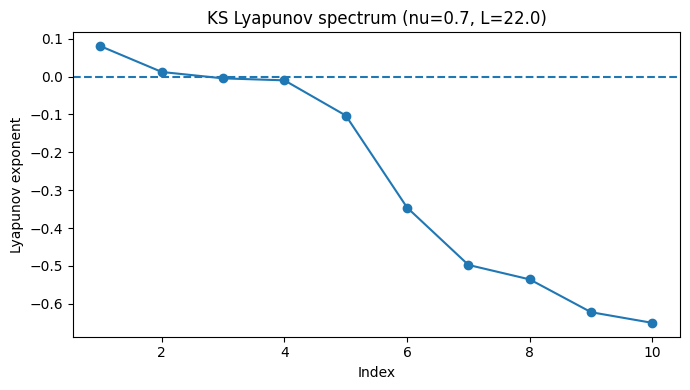

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi as PI



# Initial conditions


def init_u(x, L, Mx):
    u0 = 0.06 * (
        np.cos(2 * PI * x / L)
        + np.cos(2 * 2 * PI * x / L)
        + np.cos(3 * 2 * PI * x / L)
        + np.cos(4 * 2 * PI * x / L)
    )
    u0[0] += 1e-5
    return u0


def init_u_1(x, L, Mx):
    u0 = 0.06 * (
        np.cos(1 * 2 * PI * x / L)
        + np.cos(3 * 2 * PI * x / L)
        + np.cos(4 * 2 * PI * x / L)
        + np.cos(5 * 2 * PI * x / L)
    )
    u0[0] += 1e-5
    return u0


def init_u_2(x, L, Mx):
    u0 = 0.07 * (
        np.cos(1 * 2 * PI * x / L)
        + np.cos(2 * 2 * PI * x / L)
        + np.cos(4 * 2 * PI * x / L)
        + np.cos(5 * 2 * PI * x / L)
    )
    u0[0] += 1e-5
    return u0


def init_u_3(x, L, Mx):
    u0 = 0.08 * (
        np.cos(2 * 2 * PI * x / L)
        + np.cos(3 * 2 * PI * x / L)
        + np.cos(4 * 2 * PI * x / L)
        + np.cos(5 * 2 * PI * x / L)
    )
    u0[0] += 1e-5
    return u0


def init_u_4(x, L, Mx):
    u0 = 0.09 * (
        np.cos(1 * 2 * PI * x / L)
        + np.cos(2 * 2 * PI * x / L)
        + np.cos(3 * 2 * PI * x / L)
        + np.cos(5 * 2 * PI * x / L)
    )
    u0[0] += 1e-5
    return u0


def init_u_5(x, L, Mx):
    u0 = 0.01 * (
        np.cos(2 * PI * x / L)
        + np.cos(2 * 2 * PI * x / L)
        + np.cos(3 * 2 * PI * x / L)
        + np.cos(5 * 2 * PI * x / L)
    )
    u0[0] += 1e-5
    return u0


def init_u_6(x, L, Mx):
    u0 = 0.02 * (
        np.cos(2 * PI * x / L)
        + np.cos(2 * 2 * PI * x / L)
        + np.cos(4 * 2 * PI * x / L)
        + np.cos(6 * 2 * PI * x / L)
    )
    u0[0] += 1e-5
    return u0



def wavenumbers(Mx, L):
    return np.fft.rfftfreq(Mx, d=L / Mx) * 2 * PI


def freq_squared_with_n(u_hat, Mx):
    ureal = np.fft.irfft(u_hat, n=Mx)
    nlt = ureal.real * ureal.real
    return np.fft.rfft(nlt)




def kssol_segment(u0, Mx, L, dt, nsteps, nu, store_all=False):
    x = np.linspace(0, L, Mx, endpoint=False)
    kx = wavenumbers(Mx, L)

    # linear operator corresponding to u_xx + nu u_xxxx
    k2 = -(kx ** 2) + nu * (kx ** 4)

    n_modes = k2.shape[0]
    A = np.ones((n_modes,), dtype=np.float64)

    u0 = np.asarray(u0, dtype=np.float64).copy()

    if store_all:
        u = np.empty((Mx, nsteps + 1), dtype=np.float64)
        u_hat = np.empty((n_modes, nsteps + 1), dtype=np.complex128)
        usqr_hat = np.empty((n_modes, nsteps + 1), dtype=np.complex128)
        nlin_term = np.empty((n_modes, nsteps + 1), dtype=np.complex128)

        u[:, 0] = u0
        u_hat[:, 0] = np.fft.rfft(u0)
        u_hat[0, 0] = 0.0

        usqr_hat[:, 0] = freq_squared_with_n(u_hat[:, 0], Mx)
        nlin_term[:, 0] = -0.5 * 1j * kx * usqr_hat[:, 0]

        for i in range(nsteps):
            if i == 0:
                us0 = (u_hat[:, i] + dt * nlin_term[:, i]) / (A + dt * k2)
                us0[0] = 0.0

                nls = freq_squared_with_n(0.5 * (u_hat[:, i] + us0), Mx)
                nlspec = -0.5 * 1j * kx * nls

                u_hat[:, i + 1] = (
                    u_hat[:, i]
                    - 0.5 * dt * k2 * u_hat[:, i]
                    + dt * nlspec
                ) / (A + 0.5 * dt * k2)

            elif i == 1:
                usqr_hat[:, i] = freq_squared_with_n(u_hat[:, i], Mx)
                nlin_term[:, i] = -0.5 * 1j * kx * usqr_hat[:, i]

                u_hat[:, i + 1] = (
                    (4 * u_hat[:, i]) - u_hat[:, i - 1]
                    + (4 * dt * nlin_term[:, i]) - (2 * dt * nlin_term[:, i - 1])
                ) / ((3 * A) + (2 * dt * k2))

            else:
                usqr_hat[:, i] = freq_squared_with_n(u_hat[:, i], Mx)
                nlin_term[:, i] = -0.5 * 1j * kx * usqr_hat[:, i]

                u_hat[:, i + 1] = (
                    (18 * u_hat[:, i]) - (9 * u_hat[:, i - 1]) + (2 * u_hat[:, i - 2])
                    + (18 * dt * nlin_term[:, i]) - (18 * dt * nlin_term[:, i - 1]) + (6 * dt * nlin_term[:, i - 2])
                ) / ((11 * A) + (6 * dt * k2))

            u_hat[0, i + 1] = 0.0
            u[:, i + 1] = np.fft.irfft(u_hat[:, i + 1], n=Mx)

        return u, u_hat

    else:
        u_hist = np.empty((Mx, 3), dtype=np.float64)
        uh_hist = np.empty((n_modes, 3), dtype=np.complex128)
        usqr_hist = np.empty((n_modes, 3), dtype=np.complex128)
        nlin_hist = np.empty((n_modes, 3), dtype=np.complex128)

        u_hist[:, 0] = u0
        uh_hist[:, 0] = np.fft.rfft(u0)
        uh_hist[0, 0] = 0.0

        usqr_hist[:, 0] = freq_squared_with_n(uh_hist[:, 0], Mx)
        nlin_hist[:, 0] = -0.5 * 1j * kx * usqr_hist[:, 0]

        if nsteps == 0:
            return u0.copy()

        for i in range(nsteps):
            i0 = i % 3
            i1 = (i + 1) % 3
            im1 = (i - 1) % 3
            im2 = (i - 2) % 3

            if i == 0:
                us0 = (uh_hist[:, i0] + dt * nlin_hist[:, i0]) / (A + dt * k2)
                us0[0] = 0.0

                nls = freq_squared_with_n(0.5 * (uh_hist[:, i0] + us0), Mx)
                nlspec = -0.5 * 1j * kx * nls

                uh_hist[:, i1] = (
                    uh_hist[:, i0]
                    - 0.5 * dt * k2 * uh_hist[:, i0]
                    + dt * nlspec
                ) / (A + 0.5 * dt * k2)

            elif i == 1:
                usqr_hist[:, i0] = freq_squared_with_n(uh_hist[:, i0], Mx)
                nlin_hist[:, i0] = -0.5 * 1j * kx * usqr_hist[:, i0]

                uh_hist[:, i1] = (
                    (4 * uh_hist[:, i0]) - uh_hist[:, im1]
                    + (4 * dt * nlin_hist[:, i0]) - (2 * dt * nlin_hist[:, im1])
                ) / ((3 * A) + (2 * dt * k2))

            else:
                usqr_hist[:, i0] = freq_squared_with_n(uh_hist[:, i0], Mx)
                nlin_hist[:, i0] = -0.5 * 1j * kx * usqr_hist[:, i0]

                uh_hist[:, i1] = (
                    (18 * uh_hist[:, i0]) - (9 * uh_hist[:, im1]) + (2 * uh_hist[:, im2])
                    + (18 * dt * nlin_hist[:, i0]) - (18 * dt * nlin_hist[:, im1]) + (6 * dt * nlin_hist[:, im2])
                ) / ((11 * A) + (6 * dt * k2))

            uh_hist[0, i1] = 0.0
            u_hist[:, i1] = np.fft.irfft(uh_hist[:, i1], n=Mx)

        return u_hist[:, nsteps % 3].copy()




def orthonormal_random_directions(Mx, m, seed=0, zero_mean=True):
    rng = np.random.default_rng(seed)
    Q = rng.standard_normal((Mx, m))

    if zero_mean:
        Q = Q - Q.mean(axis=0, keepdims=True)

    Q, _ = np.linalg.qr(Q)
    return Q[:, :m]


def project_zero_mean(V):
    return V - V.mean(axis=0, keepdims=True)


# Lyapunov spectrum


def lyapunov_spectrum_ks(
    Mx=255,
    L=32.0,
    nu=0.8,
    dt=None,
    Tf=None,
    nt=None,
    m=16,
    tau=100.0,
    T=2.0,
    N=200,
    eps=1e-6,
    u0=None,
    init_choice="default",
    seed=0,
    zero_mean_perturbations=True,
    return_history=True,
    verbose=True,
):


    if dt is None:
        if Tf is None or nt is None:
            raise ValueError("Provide either dt directly, or both Tf and nt.")
        dt = Tf / nt

    if m > Mx:
        raise ValueError("m cannot exceed state dimension Mx.")

    n_tau = int(round(tau / dt))
    n_T = int(round(T / dt))

    if n_T < 1:
        raise ValueError("T is too small relative to dt.")

    T_effective = n_T * dt
    tau_effective = n_tau * dt

    x = np.linspace(0, L, Mx, endpoint=False)

    if u0 is None:
        if init_choice == "default":
            u0 = init_u(x, L, Mx)
        elif init_choice == "u1":
            u0 = init_u_1(x, L, Mx)
        elif init_choice == "u2":
            u0 = init_u_2(x, L, Mx)
        elif init_choice == "u3":
            u0 = init_u_3(x, L, Mx)
        elif init_choice == "u4":
            u0 = init_u_4(x, L, Mx)
        elif init_choice == "u5":
            u0 = init_u_5(x, L, Mx)
        elif init_choice == "u6":
            u0 = init_u_6(x, L, Mx)
        else:
            raise ValueError(f"Unknown init_choice={init_choice}")
    else:
        u0 = np.asarray(u0, dtype=np.float64).copy()

    if zero_mean_perturbations:
        u0 = u0 - np.mean(u0)

    if verbose:
        print(f"dt               = {dt}")
        print(f"tau              = {tau_effective}")
        print(f"T                = {T_effective}")
        print(f"N                = {N}")
        print(f"m                = {m}")
        print(f"eps              = {eps}")
        print("Integrating transient...")

    u_base = kssol_segment(u0, Mx, L, dt, n_tau, nu, store_all=False)

    Q = orthonormal_random_directions(Mx, m, seed=seed, zero_mean=zero_mean_perturbations)
    log_diag_R_sum = np.zeros(m, dtype=np.float64)

    if return_history:
        lambda_history = np.zeros((N, m), dtype=np.float64)
        Rdiag_history = np.zeros((N, m), dtype=np.float64)
    else:
        lambda_history = None
        Rdiag_history = None

    for j in range(N):
        if verbose and ((j + 1) % max(1, N // 10) == 0 or j == 0):
            print(f"QR step {j + 1}/{N}")

        u_next = kssol_segment(u_base, Mx, L, dt, n_T, nu, store_all=False)

        PsiQ = np.zeros((Mx, m), dtype=np.float64)

        for i in range(m):
            u_pert0 = u_base + eps * Q[:, i]
            if zero_mean_perturbations:
                u_pert0 = u_pert0 - np.mean(u_pert0)

            w_i = kssol_segment(u_pert0, Mx, L, dt, n_T, nu, store_all=False)
            PsiQ[:, i] = (w_i - u_next) / eps

        if zero_mean_perturbations:
            PsiQ = project_zero_mean(PsiQ)

        Q, R = np.linalg.qr(PsiQ)

        diagR = np.diag(R)
        diagR_abs = np.abs(diagR)
        diagR_abs = np.maximum(diagR_abs, 1e-300)

        log_diag_R_sum += np.log(diagR_abs)
        lambdas_running = log_diag_R_sum / ((j + 1) * T_effective)

        if return_history:
            lambda_history[j] = lambdas_running
            Rdiag_history[j] = diagR_abs

        u_base = u_next

    result = {
        "lyapunov_exponents": log_diag_R_sum / (N * T_effective),
        "lambda_history": lambda_history,
        "Rdiag_history": Rdiag_history,
        "Q_final": Q,
        "u_final": u_base,
        "dt": dt,
        "tau_effective": tau_effective,
        "T_effective": T_effective,
        "n_tau": n_tau,
        "n_T": n_T,
        "N": N,
        "m": m,
        "eps": eps,
    }
    return result

# Plots

def plot_lyapunov_spectrum(les, title="Lyapunov spectrum"):
    plt.figure(figsize=(7, 4))
    plt.plot(np.arange(1, len(les) + 1), les, marker="o")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Index")
    plt.ylabel("Lyapunov exponent")
    plt.title(title)
    plt.tight_layout()
    plt.show()





if __name__ == "__main__":
    nu = 0.7
    L = 22.
    Mx = 1024
    Tf = 2.5 * 1000
    nt = 10000
    dt = Tf / nt # here, dt is .25 for tf 2500 and nt 10000

    result = lyapunov_spectrum_ks(
        Mx=Mx,
        L=L,
        nu=nu,
        dt=dt,
        m=10,
        tau=100.0,
        T=2.0,
        N=2000,
        eps=1e-6,
        init_choice="u1",
        seed=0,
        return_history=True,
        verbose=True,
    )

    les = result["lyapunov_exponents"]

    print("\nLeading Lyapunov exponents:")
    for i, val in enumerate(les, start=1):
        print(f"lambda_{i:02d} = {val:.10f}")

    plot_lyapunov_spectrum(les, title=f"KS Lyapunov spectrum (nu={nu}, L={L})")


In [3]:
lyapunov_time = 1/les[0]
print(f"Lyapunov_time: {lyapunov_time}\n"
      f"Lyapunov exponents: {les}")

Lyapunov_time: 12.478292398441297
Lyapunov exponents: [ 0.08013917  0.01199152 -0.0048298  -0.0100954  -0.10297024 -0.34597156
 -0.49737414 -0.53556353 -0.62212378 -0.65032149]
